In [1]:
# --- Core Libraries ---
import sys
import os

# --- Data Handling and Numerical Operations ---
import numpy as np
import pandas as pd

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning and Deep Learning ---
import sklearn.datasets
import sklearn.model_selection
import sklearn.preprocessing
import sklearn.pipeline
import sklearn.compose
import sklearn.linear_model
import sklearn.svm
import sklearn.neural_network
import tensorflow as tf

# 1. Introduction to TensorFlow Fundamentals

This section serves as a practical introduction to the core components of TensorFlow, a premier open-source platform for machine learning. We will explore the building blocks of this powerful library, focusing on:

- **Tensors:** The fundamental data structure in TensorFlow. Tensors are multi-dimensional arrays with support for GPU acceleration, making them ideal for the high-performance numerical computations required in deep learning.
- **Variables:** Special tensors used to hold mutable state, such as the weights and biases of a machine learning model. These are the parameters that a model learns during the training process.
- **Basic Operations:** A tour of essential mathematical and manipulation operations that can be performed on tensors. These operations form the basis of all model computations, from simple arithmetic to complex transformations.

The goal is to build a foundational understanding of how to create, manipulate, and operate on these core elements. A solid grasp of these concepts is crucial before moving on to building and training sophisticated machine learning models.

## **1.1. Tensor Creation: Constants and Variables**

In TensorFlow, all data is represented using **tensors**. These are the primary data structures that flow through computational graphs. There are two main types:

- **`tf.constant`**: These are **immutable** tensors. Once their value is set, it cannot be changed. They are ideal for holding fixed data that will not be modified during model training, such as input features or configuration parameters.

- **`tf.Variable`**: These are **mutable** tensors designed specifically to store and update the state of your model. The primary use case is to hold the model parameters—such as weights and biases—that are adjusted during the training process to minimize the loss function.

This subsection demonstrates how to create both types of tensors and highlights their fundamental difference in modifiability, which is a key concept in building trainable models.

In [2]:
# Create a NumPy array, which is a familiar structure.
# This array is inherently modifiable.
array_a = np.array([[[1, 2],
                     [3, 4]],

                    [[5, 6],
                     [7, 8]]])

# Display the basic properties of the NumPy array.
print("--- NumPy Array Properties ---",
      f"Shape: {array_a.shape}",
      f"Data Type: {array_a.dtype}",
      sep="\n",
      end="\n\n"
)

# --- Demonstrating TensorFlow Constant Creation ---
# TensorFlow provides several convenient functions to create common tensors.
print("--- TensorFlow Constant Creation Examples ---",
    # Create a constant tensor from a list with a specific data type and shape.
    "From a list:\n" + str(tf.constant([1, 2, 3, 4], dtype=tf.int8, shape=(2, 2)).numpy()),
    # Create a tensor of all ones with a given shape.
    "Tensor of ones:\n" + str(tf.ones((2, 2, 2)).numpy()),
    # Create a tensor of ones with the same shape as an existing array/tensor.
    "Ones like another tensor:\n" + str(tf.ones_like(array_a).numpy()),
    # Create a tensor of all zeros.
    "Tensor of zeros:\n" + str(tf.zeros((2, 2, 2)).numpy()),
    # Create a tensor of zeros with the same shape as an existing array/tensor.
    "Zeros like another tensor:\n" + str(tf.zeros_like(array_a).numpy()),
    # Create a tensor filled with a specific scalar value.
    "Filled tensor:\n" + str(tf.fill([2, 2], value=7).numpy()),
sep="\n\n")

# --- Creating a TensorFlow Variable ---
# A tf.Variable holds state and can be updated. It's essential for model parameters.
print("--- TensorFlow Variable ---")
print(tf.Variable([1, 2, 3]))

--- NumPy Array Properties ---
Shape: (2, 2, 2)
Data Type: int64

--- TensorFlow Constant Creation Examples ---

From a list:
[[1 2]
 [3 4]]

Tensor of ones:
[[[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]]

Ones like another tensor:
[[[1 1]
  [1 1]]

 [[1 1]
  [1 1]]]

Tensor of zeros:
[[[0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]]]

Zeros like another tensor:
[[[0 0]
  [0 0]]

 [[0 0]
  [0 0]]]

Filled tensor:
[[7 7]
 [7 7]]
--- TensorFlow Variable ---
<tf.Variable 'Variable:0' shape=(3,) dtype=int32, numpy=array([1, 2, 3], dtype=int32)>


In [3]:
# --- Immutability of `tf.constant` ---
# Create a constant tensor.
tensor_a = tf.constant(np.random.RandomState(13).binomial(10, 0.5, size=(2, 3, 3)), dtype=tf.int8)

# Attempting to modify an element of a constant tensor will raise an error.
# The `.assign()` method is used for updating variables, not constants.
try:
    tensor_a[0, 0, 0].assign(1)
except Exception as e:
    print(f"--- Attempting to Modify a `tf.constant` ---")
    print(f"Error: Constant tensors are immutable. The operation failed as expected.")
    print(f"Original tensor remains unchanged:\n{tensor_a.numpy()}\n")

# --- Mutability of `tf.Variable` ---
# Create a variable from the constant tensor. Variables are designed to be modified.
tensor_b = tf.Variable(tensor_a)

# Use the `.assign()` method to update a specific element of the variable.
# This operation succeeds because `tensor_b` is a `tf.Variable`.
print(f"--- Modifying a `tf.Variable` ---")
print(f"Original variable:\n{tensor_b.numpy()}\n")
tensor_b[0, 0, 0].assign(1)
print(f"Variable after modification:\n{tensor_b.numpy()}")

--- Attempting to Modify a `tf.constant` ---
Error: Constant tensors are immutable. The operation failed as expected.
Original tensor remains unchanged:
[[[6 4 6]
  [8 8 5]
  [5 6 6]]

 [[6 2 4]
  [3 7 4]
  [6 4 4]]]

--- Modifying a `tf.Variable` ---
Original variable:
[[[6 4 6]
  [8 8 5]
  [5 6 6]]

 [[6 2 4]
  [3 7 4]
  [6 4 4]]]

Variable after modification:
[[[1 4 6]
  [8 8 5]
  [5 6 6]]

 [[6 2 4]
  [3 7 4]
  [6 4 4]]]


## **1.2. Basic Tensor Operations**

Just like with NumPy arrays, TensorFlow allows for a wide range of mathematical operations on tensors. These operations are highly optimized for performance, automatically leveraging available hardware like GPUs. This section covers fundamental element-wise and matrix operations that are the building blocks of any machine learning model's forward pass.

We will demonstrate:
- **Scalar Multiplication:** Scaling a tensor's values.
- **Transposition:** Swapping a tensor's dimensions.
- **Concatenation:** Joining tensors along a specified axis.
- **Element-wise Arithmetic:** Performing addition, subtraction, and multiplication between corresponding tensor elements.
- **Matrix Multiplication:** Computing the dot product, a cornerstone of linear algebra and neural networks.

In [4]:
# Define two constant tensors for our operations.
# Using float16 for memory efficiency where high precision is not critical.
tensor_a = tf.constant([1, 2, 3, 4], dtype=tf.float16, shape=[2, 2])
# An identity matrix is useful for many linear algebra operations.
tensor_b = tf.constant(np.identity(2), dtype=tf.float16)

print(f"--- Initial Tensors --- \nTensor A:\n{tensor_a.numpy()} \n\nTensor B (Identity Matrix):\n{tensor_b.numpy()}\n")

print(
    "--- Tensor Operations ---",
    # Scalar multiplication scales all elements of the tensor.
    f"Scalar Multiplication (B * 5):\n{ (tensor_b * 5).numpy() }",
    # Transposing swaps the axes of a tensor.
    f"Transpose of A:\n{ tf.transpose(tensor_a).numpy() }",
    # Concatenation joins tensors along a specified axis. Here, we stack them vertically (axis=0).
    f"Concatenation of A with itself (axis=0):\n{ tf.concat([tensor_a, tensor_a], axis=0).numpy() }",
    # Element-wise operations are performed between corresponding elements of tensors.
    f"Element-wise Addition (A + B):\n{ tf.add(tensor_a, tensor_b).numpy() }",
    f"Element-wise Subtraction (A - B):\n{ tf.subtract(tensor_a, tensor_b).numpy() }",
    f"Element-wise Multiplication (A * B):\n{ tf.multiply(tensor_a, tensor_b).numpy() }",
    # Matrix multiplication follows the rules of linear algebra (dot product).
    f"Matrix Multiplication (A @ B):\n{ tf.matmul(tensor_a, tensor_b).numpy() }",
    sep="\n\n"
)

--- Initial Tensors --- 
Tensor A:
[[1. 2.]
 [3. 4.]] 

Tensor B (Identity Matrix):
[[1. 0.]
 [0. 1.]]

--- Tensor Operations ---

Scalar Multiplication (B * 5):
[[5. 0.]
 [0. 5.]]

Transpose of A:
[[1. 3.]
 [2. 4.]]

Concatenation of A with itself (axis=0):
[[1. 2.]
 [3. 4.]
 [1. 2.]
 [3. 4.]]

Element-wise Addition (A + B):
[[2. 2.]
 [3. 5.]]

Element-wise Subtraction (A - B):
[[0. 2.]
 [3. 3.]]

Element-wise Multiplication (A * B):
[[1. 0.]
 [0. 4.]]

Matrix Multiplication (A @ B):
[[1. 2.]
 [3. 4.]]


In [5]:
# --- Demonstrating Dimensional Aggregation (Reduction) ---
# Reduction operations summarize tensor data along one or more axes.
# Create a 3D tensor to illustrate reduction along different axes.
ones_tensor = tf.ones([2, 3, 4]) # Shape: (depth, height, width)

print("--- Original 3D Tensor of Ones (Shape: 2, 3, 4) ---\n")

# `tf.reduce_sum` is a common reduction operation.
print(
    # axis=0: Sums the elements across the 'depth' dimension.
    # The two 3x4 matrices are added together element-wise.
    f"Sum along axis=0 (Result Shape: 3x4):\n{tf.reduce_sum(ones_tensor, axis=0).numpy()}",

    # axis=1: Sums the elements across the 'height' (rows) dimension for each matrix.
    f"Sum along axis=1 (Result Shape: 2x4):\n{tf.reduce_sum(ones_tensor, axis=1).numpy()}",

    # axis=2: Sums the elements across the 'width' (columns) dimension for each matrix.
    f"Sum along axis=2 (Result Shape: 2x3):\n{tf.reduce_sum(ones_tensor, axis=2).numpy()}",

    sep="\n\n"
)

--- Original 3D Tensor of Ones (Shape: 2, 3, 4) ---

Sum along axis=0 (Result Shape: 3x4):
[[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]

Sum along axis=1 (Result Shape: 2x4):
[[3. 3. 3. 3.]
 [3. 3. 3. 3.]]

Sum along axis=2 (Result Shape: 2x3):
[[4. 4. 4.]
 [4. 4. 4.]]


## **1.3. Tensor Slicing and Indexing**

Slicing and indexing are essential skills for accessing and manipulating specific parts of a tensor. The syntax is intentionally similar to NumPy, making it intuitive for anyone with a background in Python's scientific computing stack. This section provides a practical demonstration of how to select elements, rows, columns, and sub-tensors from both 2D (matrices) and 3D tensors, which is a common requirement in data preparation and model analysis.

### **1.3.1. Slicing a 2D Tensor (Matrix)**

In [6]:
# Create a base 2D tensor (a 5x5 matrix) for slicing demonstrations.
# We start with a 1D range and reshape it.
tensor_a = tf.Variable(np.arange(25))
tensor_a = tf.reshape(tensor_a, shape=[5, 5])
print("--- Base 5x5 Matrix for Slicing ---")
tensor_a.numpy()

--- Base 5x5 Matrix for Slicing ---


array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [7]:
# --- Demonstrating various slicing techniques on the 2D matrix ---
print(
    # Get a single element at a specific index (row 0, column 0).
    f"Get a single element [0, 0]: {tensor_a[0, 0].numpy()}",

    # Get an entire row (the first row).
    f"Get the first row [0]: {tensor_a[0].numpy()}",

    # Get elements from the first row with a step (every 3rd element).
    f"Get elements from the first row with a step [0, ::3]: {tensor_a[0, ::3].numpy()}",

    # Get a slice of continuous rows (the first two rows).
    f"Get the first two rows [:2]:\n{tensor_a[:2].numpy()}",

    # Get non-continuous rows using a step (every 2nd row, up to the 3rd).
    f"Get non-continuous rows [:3:2, :]:\n{tensor_a[:3:2, :].numpy()}",

    # Slice a sub-matrix by specifying row and column ranges.
    f"Slice a sub-matrix [2:4, 1:3]:\n{tensor_a[2:4, 1:3].numpy()}",

    sep="\n\n"
)

Get a single element [0, 0]: 0

Get the first row [0]: [0 1 2 3 4]

Get elements from the first row with a step [0, ::3]: [0 3]

Get the first two rows [:2]:
[[0 1 2 3 4]
 [5 6 7 8 9]]

Get non-continuous rows [:3:2, :]:
[[ 0  1  2  3  4]
 [10 11 12 13 14]]

Slice a sub-matrix [2:4, 1:3]:
[[11 12]
 [16 17]]


### **1.3.2. Slicing a 3D Tensor**

In [8]:
# Create a 3D tensor for slicing demonstrations.
# The shape will be (2, 3, 3), representing 2 matrices of size 3x3.
tensor_b = tf.constant(np.arange(18).reshape(-1, 3, 3))
print("--- Base 3D Tensor (Shape: 2, 3, 3) ---")
print(f"Tensor Content:\n{tensor_b.numpy()}",
      f"Dimensions: {tensor_b.ndim}",
      f"Shape: {tensor_b.shape}",
      sep="\n\n")

--- Base 3D Tensor (Shape: 2, 3, 3) ---
Tensor Content:
[[[ 0  1  2]
  [ 3  4  5]
  [ 6  7  8]]

 [[ 9 10 11]
  [12 13 14]
  [15 16 17]]]

Dimensions: 3

Shape: (2, 3, 3)


In [9]:
# --- Demonstrating various slicing techniques on the 3D tensor ---
print(
    # Get a single scalar value from a specific location (matrix 0, row 1, column 1).
    f"Get a single element [0, 1, 1]: {tensor_b[0, 1, 1].numpy()}",

    # Extract a 1D vector (row 1 from matrix 0).
    f"Extract a 1D row [0, 1]: {tensor_b[0, 1].numpy()}",

    # Extract a 2D matrix by selecting the same row from all matrices in the tensor.
    f"Extract a 2D slice [:, 1]:\n{tensor_b[:, 1].numpy()}",

    # Perform a more complex slice across all three dimensions.
    # Selects all matrices, every second row, and the first two columns.
    f"Complex slice [:, ::2, :2]:\n{tensor_b[:, ::2, :2].numpy()}",

    sep="\n\n"
)

Get a single element [0, 1, 1]: 4

Extract a 1D row [0, 1]: [3 4 5]

Extract a 2D slice [:, 1]:
[[ 3  4  5]
 [12 13 14]]

Complex slice [:, ::2, :2]:
[[[ 0  1]
  [ 6  7]]

 [[ 9 10]
  [15 16]]]


# 2. Training a Simple Model with TensorFlow

Now that we have a grasp of the fundamentals, we can move on to a core machine learning task: training a model. This section demonstrates how to build and train a simple models from scratch using TensorFlow's low-level APIs.

## **2.1. Simple Linear Regression with Gradient Descent**
The process involves several key steps:
1.  **Data Simulation:** We will create a synthetic dataset based on a known linear relationship, adding some random noise to mimic the variability and imperfections of real-world data.
2.  **Model Definition:** We will define the structure of our linear model, which is a simple equation representing a line.
3.  **Loss Function:** We will implement a function to measure how well our model's predictions match the actual data. This metric will guide the training process.
4.  **Custom Training Loop:** We will implement a training loop that uses **gradient descent** to iteratively update the model's parameters (weight and bias). This process involves using `tf.GradientTape` to automatically compute the gradients of the loss with respect to the parameters, which is the cornerstone of modern autodifferentiation in deep learning.

This hands-on example is designed to demystify the training process, providing a clear and concise guide to the mechanics of how a model learns from data in TensorFlow.

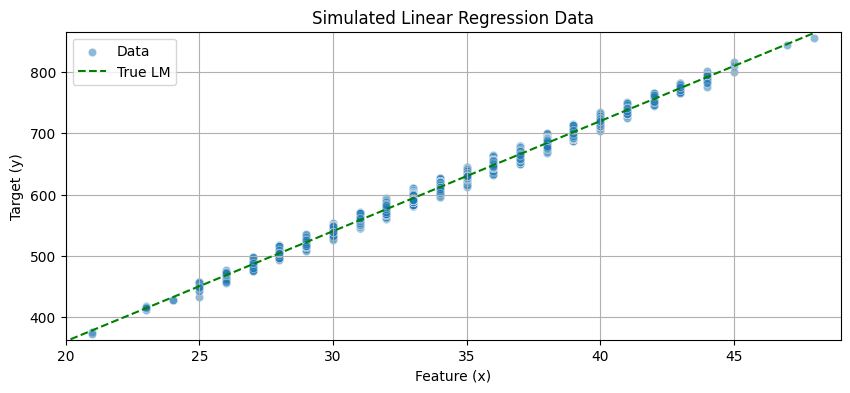

--- True Underlying Parameters ---
Weight: 18, Bias: 0


In [10]:
# --- Step 1: Simulate a Dataset for Linear Regression ---

# Use a fixed random state for reproducibility.
base_seed = np.random.RandomState(13)

# Define the "true" parameters of our linear model.
# Our goal is for the model to learn values close to these.
true_weight = base_seed.randint(0, 50, size=1)
true_bias = base_seed.randint(0, 10, size=1)

# Generate the input features 'x' from a binomial distribution.
# We cast to float64 to ensure compatibility with model parameters.
x = tf.constant(base_seed.binomial(n=50, p=0.70, size=10000), dtype=tf.float64)

# Generate the target variable 'y'.
# It's a linear function of 'x' plus some Gaussian noise to make it more realistic.
y = tf.constant((x * true_weight) + true_bias + base_seed.normal(loc=0, scale=5, size=x.shape[0]), dtype=tf.float64)

# --- Visualize the Simulated Data ---
fig, ax = plt.subplots(figsize=(10, 4))
# Create a scatter plot of the data points.
sns.scatterplot(y=y.numpy(), x=x.numpy(), ax=ax, alpha=0.5, label="Data")
# Plot the "true" line that the data was generated from.
ax.plot([0, max(x)], [true_bias[0], (max(x) * true_weight[0]) + true_bias[0]], "--g", label="True LM")
plt.title("Simulated Linear Regression Data")
plt.xlabel("Feature (x)")
plt.ylabel("Target (y)")
plt.xlim(np.min(x) - 1, np.max(x) + 1)
plt.ylim(np.min(y) - 10, np.max(y) + 10)
plt.legend()
plt.grid(True)
plt.show()

print(f"--- True Underlying Parameters ---")
print(f"Weight: {true_weight[0]}, Bias: {true_bias[0]}")

In [11]:
# --- Step 2: Define the Model and Loss Function ---

# The linear model function defines the forward pass.
def linear_model(bias, weights, x: np.array = x):
    """
    Computes the model's prediction using the linear equation: y = w*x + b.
    """
    return weights * x + bias

# The loss function quantifies how far the model's predictions are from the actual targets.
def loss_function(bias, weights, x: np.array = x, y: np.array = y):
    """
    Calculates the Mean Squared Error (MSE) between predicted and actual values.
    MSE is a standard loss function for regression tasks.
    """
    y_pred = linear_model(bias=bias, weights=weights, x=x)
    return tf.keras.losses.mse(y_true=y, y_pred=y_pred)

In [12]:
# --- Step 3: Implement the Custom Training Loop ---

# Initialize the model's parameters (weights and bias) as TensorFlow Variables.
# These will be updated during training. We start with arbitrary values.
bias = tf.Variable(0.0, name="b", dtype=tf.float64)
weight = tf.Variable(np.random.RandomState(17).random(1), name="w", dtype=tf.float64)

# Set up the optimizer. Adam is a popular and effective choice.
# The learning rate controls the size of the steps the optimizer takes.
optim = tf.keras.optimizers.Adam(learning_rate=0.1)
# Define the number of training iterations.
n_epochs = 3000

# The main training loop.
for epoch in range(n_epochs):
    # Use tf.GradientTape to automatically record operations for differentiation.
    with tf.GradientTape() as tape:
        # Calculate the loss for the current parameter values.
        loss = loss_function(bias, weight, x=x, y=y)

    # Compute the gradients of the loss with respect to the trainable parameters.
    gradients = tape.gradient(loss, [bias, weight])

    # Apply the gradients to the parameters to update them.
    # This is the core step of gradient descent.
    optim.apply_gradients(zip(gradients, [bias, weight]))

    # Periodically print the training progress.
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss: {loss.numpy():.2f}, Bias: {bias.numpy():.2f}, Weight: {weight.numpy()[0]:.2f}")

print(f"\n--- Training Complete ---")
print(f"Final Learned Parameters: Bias ({bias.numpy():.2f}), Weight({weight.numpy()[0]:.2f})")

Epoch 0: Loss: 386541.53, Bias: 0.10, Weight: 0.39
Epoch 500: Loss: 28.10, Bias: 17.18, Weight: 17.49
Epoch 1000: Loss: 27.51, Bias: 17.16, Weight: 17.51
Epoch 1500: Loss: 27.49, Bias: 17.09, Weight: 17.51
Epoch 2000: Loss: 27.47, Bias: 17.00, Weight: 17.52
Epoch 2500: Loss: 27.43, Bias: 16.88, Weight: 17.52

--- Training Complete ---
Final Learned Parameters: Bias (16.73), Weight(17.53)


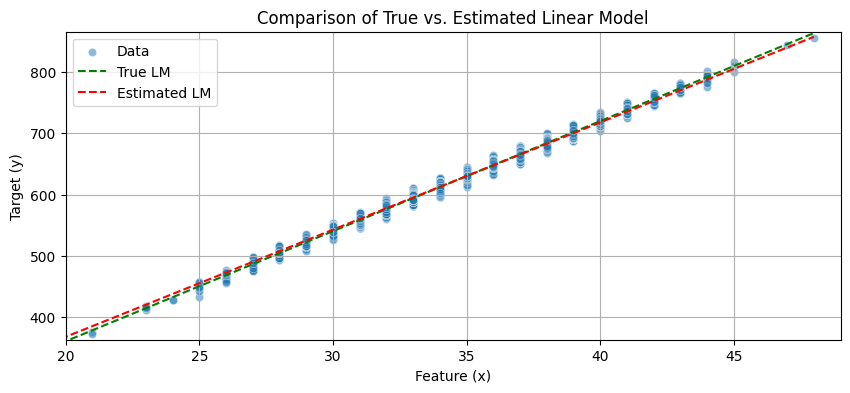

--- Parameter Comparison ---
True Parameters:      Weight -> 18.0000, Bias -> 0.0000
Estimated Parameters: Weight -> 17.5252, Bias -> 16.7271

Final Root Mean Squared Error (RMSE): 5.2336


In [13]:
# --- Step 4: Visualize and Evaluate the Results ---

fig, ax = plt.subplots(figsize=(10, 4))
# Plot the original data points.
sns.scatterplot(y=y.numpy(), x=x.numpy(), ax=ax, alpha=0.5, label="Data")
# Plot the true underlying line.
ax.plot([0, max(x)], [true_bias[0], (max(x) * true_weight[0]) + true_bias[0]], "--g", label="True LM")
# Plot the line our model has learned.
ax.plot([0, max(x)], [bias.numpy(), (max(x) * weight.numpy()[0]) + bias.numpy()], "--r", label="Estimated LM")

plt.title("Comparison of True vs. Estimated Linear Model")
plt.xlabel("Feature (x)")
plt.ylabel("Target (y)")
plt.xlim(np.min(x) - 1, np.max(x) + 1)
plt.ylim(np.min(y) - 10, np.max(y) + 10)
plt.legend()
plt.grid(True)
plt.show()

# --- Final Parameter Comparison and Error Metric ---
print(f"--- Parameter Comparison ---")
print(f"True Parameters:      Weight -> {true_weight[0]:.4f}, Bias -> {true_bias[0]:.4f}")
print(f"Estimated Parameters: Weight -> {weight.numpy()[0]:.4f}, Bias -> {bias.numpy():.4f}\n")

# Calculate the final Root Mean Squared Error (RMSE).
# This gives us a measure of the average prediction error in the original units.
rmse = tf.sqrt(loss)
print(f"Final Root Mean Squared Error (RMSE): {rmse.numpy():.4f}")

The results show that our gradient descent model successfully learned a `weight` that is very close to the true parameter. However, the learned `bias` shows a noticeable deviation from the true value. This discrepancy results in a final Root Mean Squared Error (RMSE) of approximately 5.22, which means that, on average, our model's predictions are off by about 5.22 units from the actual values.

A likely explanation for this behavior is the **Gaussian noise** we intentionally introduced into the target variable `y`. This random noise can shift the overall vertical positioning of the data cloud, making it more challenging for the model to pinpoint the exact intercept (bias) of the underlying linear relationship. While the slope (weight) was robustly identified, the bias was more sensitive to the random fluctuations. This is a common and insightful outcome when working with noisy data, highlighting the difference between a model's performance on clean, theoretical data versus more realistic, imperfect data.

## **2.2. Simple MLP for Binary Classification**

Having demonstrated a regression task, we now turn to classification. This section will walk through the process of building a simple Multi-Layer Perceptron (MLP)—a type of Artificial Neural Network (ANN)—to perform a binary classification task.

We will use the well-known **Iris dataset** and simplify the problem to a binary one: classifying whether a flower is of the species *Iris-Versicolour* or not. This example will cover the end-to-end workflow, from data preparation to model training and evaluation, providing a gentle introduction to building neural networks for classification with TensorFlow. We will also establish a benchmark using `scikit-learn`'s MLP implementation for comparison.

In [19]:
# Obtaining the data and creating train-test
data = sklearn.datasets.load_iris()
print(data.DESCR)

# Crating train-test splits and encoding the targets
x, y = data.data, data.target
y = (y == 1)
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x, y, test_size=0.2)

# Creating a K-fold split for performing cross-validation
kf = sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=15)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [37]:
%time
# Creating a simple ANN in sklearn for establishing a comparative benchmark
mlp_classifier = sklearn.pipeline.make_pipeline(
    sklearn.preprocessing.MinMaxScaler(),
    sklearn.neural_network.MLPClassifier(hidden_layer_sizes=[100, 50, 10],
                                        activation="relu",
                                        solver="sgd",
                                        learning_rate="adaptive",
                                        max_iter=300,
                                        random_state=130)
)

mlp_performance = sklearn.model_selection.cross_val_score(mlp_classifier, x_train, y_train, cv=kf, scoring="accuracy", verbose=3)
pd.Series(mlp_performance).describe()

CPU times: total: 0 ns
Wall time: 5.01 μs
[CV] END ................................ score: (test=0.542) total time=   0.1s
[CV] END ................................ score: (test=0.750) total time=   0.0s
[CV] END ................................ score: (test=0.625) total time=   0.1s
[CV] END ................................ score: (test=0.625) total time=   0.0s
[CV] END ................................ score: (test=0.625) total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.7s finished


count    5.000000
mean     0.633333
std      0.074536
min      0.541667
25%      0.625000
50%      0.625000
75%      0.625000
max      0.750000
dtype: float64

In [38]:
%time
counter = 0
for training_instances, validating_instances in kf.split(x_train):

    # Creating base_transformer
    min_max_scaler = sklearn.preprocessing.MinMaxScaler()

    # Separating train and validation test
    train, train_target = x_train[training_instances,], y_train[training_instances,]
    validation, validation_target = x_train[validating_instances,], y_train[validating_instances,]

    # Trasforming the data
    min_max_scaler = min_max_scaler.fit(train)
    train = min_max_scaler.transform(train)
    validation = min_max_scaler.transform(validation)

    # Creating MLP model
    MLP_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(50, activation="relu"),
        tf.keras.layers.Dense(10, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    # Compiling model's performance
    MLP_model.compile(optimizer="SGD", loss="binary_crossentropy", metrics=["accuracy", "precision"])

    # Fit the model on the training data and store the history
    history = MLP_model.fit(x=train, y=train_target, epochs=300, validation_data=(validation, validation_target), verbose=0)

    # Evaluate the model on the test set
    print(f"--- Validation Set Evaluation, fold {counter}---")
    validation_loss, validation_accuracy, validation_precision = MLP_model.evaluate(validation, validation_target)
    print(f"Validation Loss: {validation_loss:.4f}")
    print(f"Validation Accuracy: {validation_accuracy:.4f}")
    print(f"Validation Precision: {validation_precision:.4f}\n")
    counter += 1

CPU times: total: 0 ns
Wall time: 26 μs
--- Validation Set Evaluation, fold 0---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5417 - loss: 0.6492 - precision: 0.0000e+00
Test Loss: 0.6492
Test Accuracy: 0.5417
Test Precision: 0.0000

--- Validation Set Evaluation, fold 1---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.5310 - precision: 0.0000e+00
Test Loss: 0.5310
Test Accuracy: 0.7500
Test Precision: 0.0000

--- Validation Set Evaluation, fold 2---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6250 - loss: 0.5797 - precision: 0.0000e+00
Test Loss: 0.5797
Test Accuracy: 0.6250
Test Precision: 0.0000

--- Validation Set Evaluation, fold 3---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6250 - loss: 0.6195 - precision: 0.0000e+00
Test Loss: 0.6195
Test Accuracy: 0.6250
Test Precision: 0.0000

--- Validation Set Evaluation, fold 4---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6250 - loss: 0.5174 - precision: 0.0000e+00
Test Loss: 0.5174
T

As seen in the cross-validation results, the TensorFlow-based MLP does not appear to perform as consistently out-of-sample as the scikit-learn benchmark. This suggests that our initial architecture or training configuration may not be optimal. However, as this is a toy example designed for demonstration, we will temporarily set aside this observation and proceed with a direct evaluation on the held-out test set to complete the workflow. This will allow us to inspect the model's learning curves and finalize our initial assessment.

--- Test Set Evaluation, fold 5---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.4465 - precision: 0.0000e+00
Test Loss: 0.4465
Test Accuracy: 0.8000
Test Precision: 0.0000



Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 100)            │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,073 (23.73 KB)

 Trainable params: 6,071 (23.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

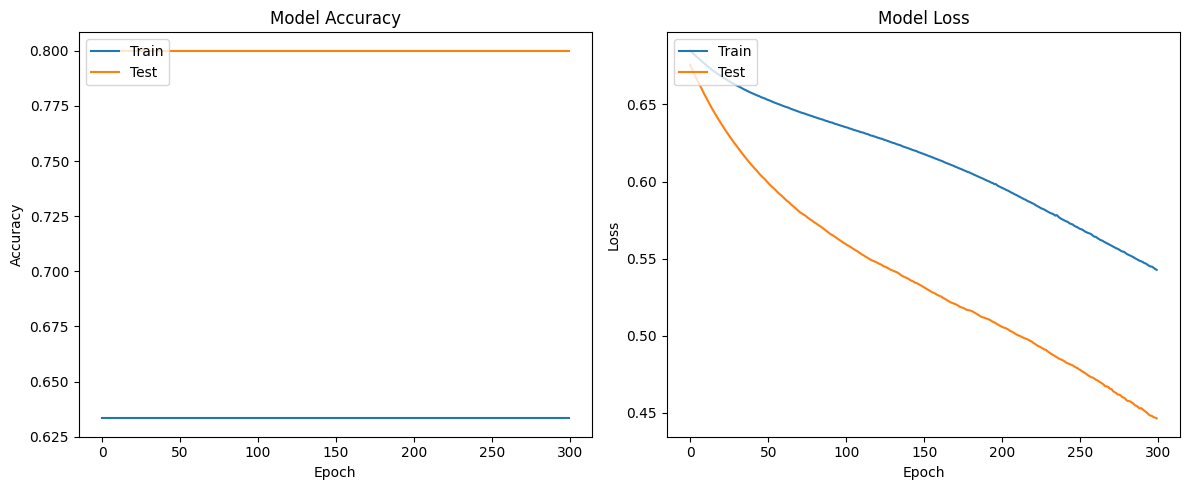

In [39]:
# Creating base_transformer
min_max_scaler = sklearn.preprocessing.MinMaxScaler()

# Trasforming the data
min_max_scaler = min_max_scaler.fit(x_train)
train = min_max_scaler.transform(x_train)
test = min_max_scaler.transform(x_test)

# Creating MLP model
MLP_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compiling model's performance
MLP_model.compile(optimizer="SGD", loss="binary_crossentropy", metrics=["accuracy", "precision"])

# Fit the model on the training data and store the history
history = MLP_model.fit(x=train, y=y_train, epochs=300, validation_data=(test, y_test), verbose=0)

# Evaluate the model on the test set
print(f"--- Test Set Evaluation, fold {counter}---")
test_loss, test_accuracy, test_precision = MLP_model.evaluate(test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}\n")

# Display the model's architecture
MLP_model.summary()

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

As suspected from the cross-validation phase and confirmed by the final evaluation on the test set, the model exhibits signs of **overfitting**. While it achieves high accuracy on the training data, its performance on unseen validation and test data is noticeably lower and more erratic, as seen in the learning curves. The validation loss fluctuates and stays higher than the training loss, indicating that the model is learning patterns specific to the training data that do not generalize well.

This behavior is likely due to a suboptimal model architecture or training configuration for this particular dataset. The model might be too complex for the amount of data available. In the next steps, one could explore several strategies to improve this result:
- **Regularization:** Add L1 or L2 regularization to the dense layers to penalize large weights.
- **Dropout:** Introduce dropout layers to randomly deactivate neurons during training, forcing the network to learn more robust features.
- **Simpler Architecture:** Reduce the number of layers or neurons to decrease the model's capacity.
- **Learning Rate Scheduling:** Use a dynamic learning rate that decreases over time.

This initial result serves as a valuable baseline and a classic example of the iterative process of model development.